Accuracy: 0.61


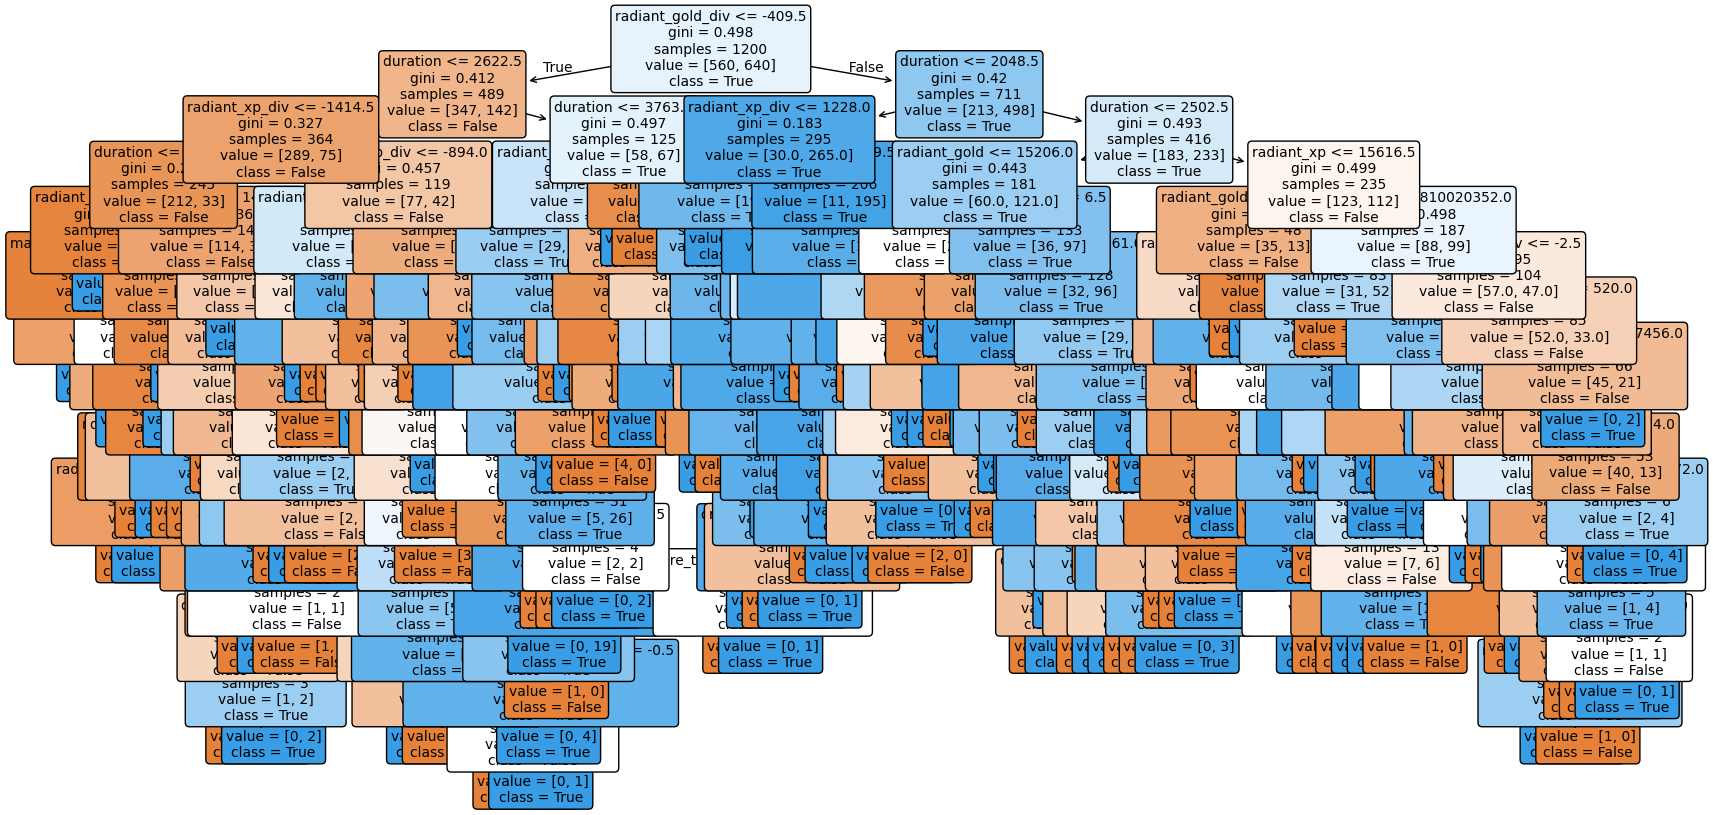

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv("match_details_output.csv")

# Split features/target
X = df.drop("radiant_win", axis=1)
y = df["radiant_win"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Decision tree model
model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=None,
    random_state=42
)
model.fit(X_train, y_train)

# Evaluate
preds = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, preds))

# Plot tree
plt.figure(figsize=(20, 10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=[str(c) for c in model.classes_],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()


In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
from xgboost import XGBClassifier

# -----------------------------
# 1. Load engineered dataset
# -----------------------------
df = pd.read_csv("match_details_output.csv")

# -----------------------------
# 2. Prepare features & target
# -----------------------------
target = "radiant_win"

# Remove identifiers that carry no predictive signal
X = df.drop(columns=["match_id", target])
y = df[target].astype(int)

# -----------------------------
# 3. Train/test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------------
# 4. Train XGBoost classifier
# -----------------------------
model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="logloss"
)

model.fit(X_train, y_train)

# -----------------------------
# 5. Evaluate model
# -----------------------------
proba = model.predict_proba(X_test)[:, 1]
pred = (proba > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, pred))
print("ROC AUC:", roc_auc_score(y_test, proba))

# -----------------------------
# 6. Predict win probability for a new 10‑min snapshot
# -----------------------------
example_row = X.iloc[[0]]  # replace with your own row
win_prob = model.predict_proba(example_row)[0][1]

print("Radiant win probability at 10 minutes:", win_prob)


Accuracy: 0.6666666666666666
ROC AUC: 0.7431642802979616
Radiant win probability at 10 minutes: 0.004088765


In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.pipeline import Pipeline

# -----------------------------
# 1. Load engineered dataset
# -----------------------------
df = pd.read_csv("match_details_output.csv")

# -----------------------------
# 2. Prepare features & target
# -----------------------------
target = "radiant_win"

X = df.drop(columns=["match_id", target])
y = df[target].astype(int)

# -----------------------------
# 3. Build a pipeline:
#    StandardScaler + LogisticRegression
# -----------------------------
model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000))
])

# -----------------------------
# 4. Train/test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------------
# 5. Train model
# -----------------------------
model.fit(X_train, y_train)

# -----------------------------
# 6. Evaluate
# -----------------------------
proba = model.predict_proba(X_test)[:, 1]
pred = (proba > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, pred))
print("ROC AUC:", roc_auc_score(y_test, proba))

# -----------------------------
# 7. Predict for a single row
# -----------------------------
example_row = X.iloc[[0]]
win_prob = model.predict_proba(example_row)[0][1]

print("Radiant win probability (logistic regression):", win_prob)
print("it ran")


Accuracy: 0.7
ROC AUC: 0.7700165038583344
Radiant win probability (logistic regression): 0.26373351583789995
it ran
